In [1]:
from google.colab import userdata, drive
import os, sys, subprocess, torch, inspect, shutil

# make pin_memory safe: skip when no GPU, and skip inside dataloader workers
# (workers are separate processes where CUDA is not initialized)
if not getattr(torch.Tensor.pin_memory, "_is_patched", False):
    import torch.utils.data as _tud
    _orig_pin = torch.Tensor.pin_memory
    def _safe_pin(self, *args, **kwargs):
        in_worker = _tud.get_worker_info() is not None
        if torch.cuda.is_available() and not in_worker:
            return _orig_pin(self, *args, **kwargs)
        return self
    _safe_pin._is_patched = True
    torch.Tensor.pin_memory = _safe_pin

if shutil.which("nvidia-smi"):
  print(subprocess.run(["nvidia-smi","--query-gpu=name,memory.total", "--format=csv,noheader"], capture_output=True, text=True).stdout)
  print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())
else:
  print("No GPU - CPU runtime")

# ---- Drive (interactive popup, once per session) ----
drive.mount('/content/drive')

PROJ  = "/content/drive/MyDrive/mit/term4"     # persistent artifacts
WORK  = "/content/work"                         # fast local scratch, wiped each session
for d in [f"{PROJ}/data", f"{PROJ}/checkpoints", f"{PROJ}/teacher_logits",
          f"{PROJ}/models", WORK]:
    os.makedirs(d, exist_ok=True)

# ---- Repo ----
REPO_DIR = "/content/emg-kd"
REPO     = "erdenebayrd/emg-kd"
TOKEN    = userdata.get("GH_TOKEN")
URL      = f"https://{TOKEN}@github.com/{REPO}.git"

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "remote", "set-url", "origin", URL], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(["git", "config", "user.email", "erdenebayr.d@gmail.com"], check=True)
subprocess.run(["git", "config", "user.name",  "Erdenebayar"], check=True)

print("cwd:", os.getcwd())
subprocess.run(["git", "-C", REPO_DIR, "log", "--oneline", "-1"])
subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"])

# ---- Drive check ----
def du(p):
    return subprocess.run(["du","-sh",p], capture_output=True, text=True).stdout.strip()
print("\nDrive project root:", PROJ)
for d in ["data","checkpoints","teacher_logits","models"]:
    print(" ", du(f"{PROJ}/{d}"))

# ---- Dataset: Drive tarball -> local scratch -> extracted ----
import time

TAR_DRIVE = f"{PROJ}/data/emg_data.tar.gz"
TAR_LOCAL = f"{WORK}/emg_data.tar.gz"
DATA_DIR  = f"{WORK}/emg_data"
os.makedirs(f"{WORK}", exist_ok=True)

if os.path.isdir(f"{DATA_DIR}/silent_parallel_data"):
    print("\ndataset already extracted:", DATA_DIR)
else:
    if not os.path.exists(TAR_LOCAL):
        assert os.path.exists(TAR_DRIVE), f"tarball missing on Drive: {TAR_DRIVE}"
        print("\ncopying tarball Drive -> local scratch ...")
        t = time.time()
        subprocess.run(["cp", TAR_DRIVE, TAR_LOCAL], check=True)
        print(f"  copied in {time.time()-t:.0f}s")
    print("extracting ...")
    t = time.time()
    subprocess.run(["tar", "-xzf", TAR_LOCAL, "-C", WORK], check=True)
    print(f"  extracted in {time.time()-t:.0f}s")

print("\ndataset:", DATA_DIR)
print(" ", du(DATA_DIR))
print("  splits:", sorted(os.listdir(DATA_DIR)))
print("  free disk:", subprocess.run(["df","-h","/content"], capture_output=True, text=True).stdout.splitlines()[1])

# ---- Reference repo (Gaddy model definitions) ----
SS_DIR = "/content/silent_speech"
if not os.path.isdir(f"{SS_DIR}/.git"):
    subprocess.run(["git","clone","--recursive",
                    "https://github.com/dgaddy/silent_speech.git", SS_DIR], check=True)
ALIGN = f"{SS_DIR}/text_alignments"
if os.path.exists(f"{ALIGN}/text_alignments.tar.gz") and not os.path.isdir(f"{ALIGN}/text_alignments"):
    subprocess.run(["tar","-xzf",f"{ALIGN}/text_alignments.tar.gz","-C",ALIGN], check=True)
if SS_DIR not in sys.path:
    sys.path.insert(0, SS_DIR)
print("\nsilent_speech repo:", SS_DIR)

# ---- Teacher checkpoint: Drive -> local scratch ----
TEACHER_DRIVE = f"{PROJ}/models/teacher_model.pt"
TEACHER       = f"{WORK}/teacher_model.pt"

assert os.path.exists(TEACHER_DRIVE), f"teacher missing on Drive: {TEACHER_DRIVE}"
if not os.path.exists(TEACHER):
    print("\ncopying teacher Drive -> local scratch ...")
    t = time.time()
    subprocess.run(["cp", TEACHER_DRIVE, TEACHER], check=True)
    print(f"  copied in {time.time()-t:.0f}s")
else:
    print("\nteacher already local:", TEACHER)

print("  teacher:", subprocess.run(["ls","-lh",TEACHER],
      capture_output=True, text=True).stdout.strip())

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__, "| device:", DEVICE)

from src.teacher import load_teacher
teacher = load_teacher(TEACHER, device=DEVICE)


# ---- Teacher logits cache: Drive zip -> local scratch ----
CACHE     = f"{WORK}/teacher_logits"
ZIP_DRIVE = f"{PROJ}/teacher_logits.zip"
ZIP_LOCAL = f"{WORK}/teacher_logits.zip"

if os.path.isdir(CACHE) and len(os.listdir(CACHE)) > 8000:
    print("\nlogits cache already extracted:", CACHE)
elif os.path.exists(ZIP_DRIVE):
    print("\nrestoring logits cache from Drive ...")
    t = time.time()
    subprocess.run(["cp", ZIP_DRIVE, ZIP_LOCAL], check=True)
    subprocess.run(["unzip", "-q", "-o", ZIP_LOCAL, "-d", WORK], check=True)
    n = len(os.listdir(CACHE)) if os.path.isdir(CACHE) else 0
    print(f"  restored {n} logit files in {time.time()-t:.0f}s")
else:
    print("\nno logits cache on Drive yet (run the caching step first)")

# ---- Train labels: Drive -> local scratch ----
LABELS_LOCAL = f"{WORK}/train_labels.pkl"
LABELS_DRIVE = f"{PROJ}/train_labels.pkl"

if os.path.exists(LABELS_LOCAL):
    print("labels already local:", LABELS_LOCAL)
elif os.path.exists(LABELS_DRIVE):
    subprocess.run(["cp", LABELS_DRIVE, LABELS_LOCAL], check=True)
    print("restored labels from Drive")
else:
    print("no labels on Drive yet (run the label caching step first)")


Tesla T4, 15360 MiB

torch: 2.11.0+cu128 | cuda available: True
Mounted at /content/drive
cwd: /content/emg-kd

Drive project root: /content/drive/MyDrive/mit/term4
  3.7G	/content/drive/MyDrive/mit/term4/data
  33M	/content/drive/MyDrive/mit/term4/checkpoints
  4.0K	/content/drive/MyDrive/mit/term4/teacher_logits
  207M	/content/drive/MyDrive/mit/term4/models

copying tarball Drive -> local scratch ...
  copied in 91s
extracting ...
  extracted in 80s

dataset: /content/work/emg_data
  6.5G	/content/work/emg_data
  splits: ['closed_vocab', 'nonparallel_data', 'silent_parallel_data', 'voiced_parallel_data']
  free disk: overlay         236G   61G  175G  26% /

silent_speech repo: /content/silent_speech

copying teacher Drive -> local scratch ...
  copied in 12s
  teacher: -rw------- 1 root root 207M Aug 17 03:50 /content/work/teacher_model.pt
torch: 2.11.0+cu128 | device: cuda


/content/silent_speech/architecture.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  self.transformer = nn.TransformerEncoder(encoder_layer, FLAGS.num_layers)



restoring logits cache from Drive ...
  restored 8055 logit files in 15s
restored labels from Drive


In [2]:
import numpy as np, json, os, glob

sess = sorted(glob.glob(f"{DATA_DIR}/silent_parallel_data/*"))[0]
print("session:", sess)

# skip sentence_index == -1 (boundary clips, not real data)
idx = None
for i in range(20):
    p = f"{sess}/{i}_info.json"
    if os.path.exists(p) and json.load(open(p))["sentence_index"] != -1:
        idx = i
        break

info = json.load(open(f"{sess}/{idx}_info.json"))
emg  = np.load(f"{sess}/{idx}_emg.npy")

print("utterance:", idx)
print("text:", info["text"])
print("emg:", emg.shape, "=", emg.shape[0]/1000, "seconds")

session: /content/work/emg_data/silent_parallel_data/5-10_silent
utterance: 1
text: XIII.
emg: (2466, 8) = 2.466 seconds


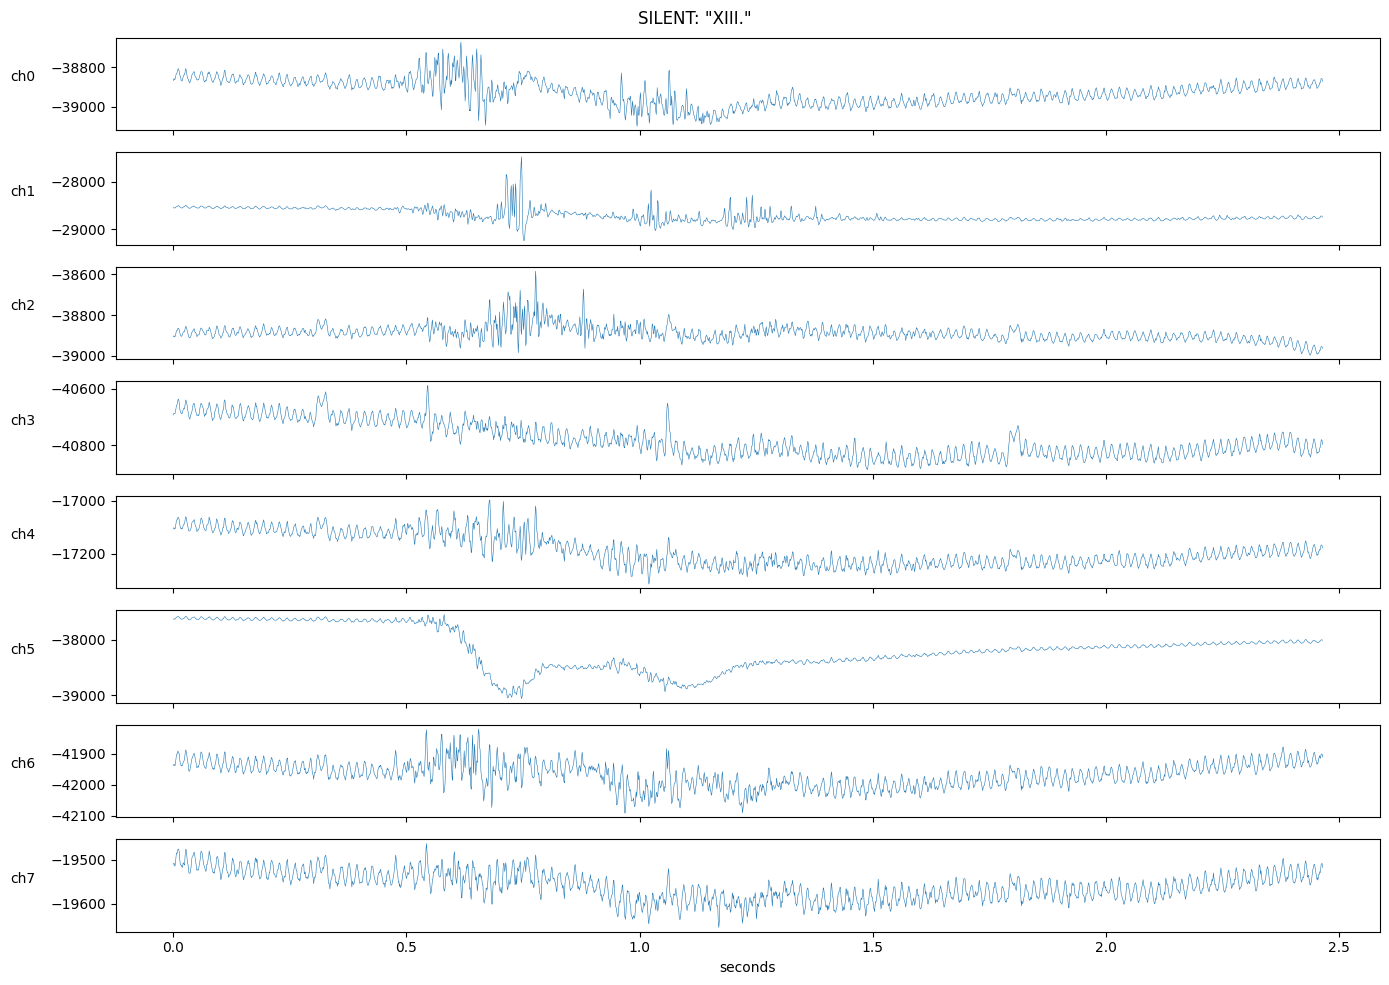

In [3]:
import matplotlib.pyplot as plt

t = np.arange(emg.shape[0]) / 1000.0
fig, axes = plt.subplots(8, 1, figsize=(14, 10), sharex=True)
for c in range(8):
    axes[c].plot(t, emg[:, c], lw=0.4)
    axes[c].set_ylabel(f"ch{c}", rotation=0, labelpad=20)
axes[-1].set_xlabel("seconds")
fig.suptitle(f'SILENT: "{info["text"]}"')
plt.tight_layout(); plt.show()

In [4]:
from IPython.display import Audio, display
import soundfile as sf

# find the matching voiced recording by book + sentence_index
target = (info["book"], info["sentence_index"])
match = None
for vs in sorted(glob.glob(f"{DATA_DIR}/voiced_parallel_data/*")):
    for p in glob.glob(f"{vs}/*_info.json"):
        vi = json.load(open(p))
        if (vi["book"], vi["sentence_index"]) == target:
            match = p.replace("_info.json", "_audio_clean.flac")
            break
    if match: break

if match:
    print("voiced version:", match)
    a, sr = sf.read(match)
    display(Audio(a, rate=sr))
else:
    print("no parallel voiced match found")

voiced version: /content/work/emg_data/voiced_parallel_data/5-10/1_audio_clean.flac


In [5]:
import os
from absl import flags
FLAGS = flags.FLAGS

from read_emg import EMGDataset

# point Gaddy's flags at your real data and repo files
FLAGS.silent_data_directories = [f"{DATA_DIR}/silent_parallel_data"]
FLAGS.voiced_data_directories = [f"{DATA_DIR}/voiced_parallel_data",
                                 f"{DATA_DIR}/nonparallel_data"]
FLAGS.testset_file    = "/content/silent_speech/testset_largedev.json"
FLAGS.normalizers_file = "/content/silent_speech/normalizers.pkl"
FLAGS.text_align_directory = "/content/silent_speech/text_alignments"

# the code uses relative 'text_alignments', so run from the repo folder
os.chdir("/content/silent_speech")


dev = EMGDataset(dev=True)
print("dev utterances:", len(dev))
print("sessions:", dev.num_sessions)
print("emg feature dim:", dev.num_features)

dev utterances: 200
sessions: 24
emg feature dim: 112


In [6]:
"""
Step 7 continued — first real utterance through the teacher

Now the real test. We take one real silent utterance, send its raw_emg through the teacher, greedy-decode the output to text, and compare to the true text.

This is the first time we see the teacher read real EMG.
"""

import torch
from data_utils import TextTransform
tt = TextTransform()

def greedy_decode(logits, blank=37):
    # logits: (T', 38) -> collapse repeats, drop blanks -> text
    ids = logits.argmax(-1).tolist()
    out, prev = [], None
    for i in ids:
        if i != blank and i != prev:
            out.append(i)
        prev = i
    return "".join(tt.chars[i] for i in out)

# pull one real silent utterance
item = dev[0]
raw = item["raw_emg"].float().unsqueeze(0).to(DEVICE)   # (1, T, 8)
true_text = item["text"]

with torch.no_grad():
    logits = teacher(None, raw, None)            # (1, T', 38)
    if isinstance(logits, tuple):
        logits = logits[0]

pred = greedy_decode(logits[0].cpu())

print("raw_emg shape:", tuple(raw.shape))
print("logits shape :", tuple(logits.shape))
print("\nTRUE:", true_text)
print("PRED:", pred)

raw_emg shape: (1, 3912, 8)
logits shape : (1, 489, 38)

TRUE: After breakfast, instead of working, I decided to walk down towards the common.
PRED: after breakfast and stead o working i desided to walk down towards the common


In [7]:
import torch, jiwer
from data_utils import TextTransform
tt = TextTransform()

def greedy_decode(logits, blank=37):
    ids = logits.argmax(-1).tolist()
    out, prev = [], None
    for i in ids:
        if i != blank and i != prev:
            out.append(i)
        prev = i
    return "".join(tt.chars[i] for i in out)

teacher.eval()
preds, refs = [], []
for k in range(len(dev)):
    item = dev[k]
    raw = item["raw_emg"].float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        lg = teacher(None, raw, None)
        if isinstance(lg, tuple):
            lg = lg[0]
    preds.append(greedy_decode(lg[0].cpu()))
    refs.append(item["text"].lower())
    if k % 50 == 0:
        print(f"  {k}/{len(dev)}")

  0/200
  50/200
  100/200
  150/200


In [8]:
import jiwer

tfm = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
])

refs_clean  = [tfm(r) for r in refs]
preds_clean = [tfm(p) for p in preds]

pairs = [(r, p) for r, p in zip(refs_clean, preds_clean) if r.strip()]
refs_clean, preds_clean = [r for r, _ in pairs], [p for _, p in pairs]

wer = jiwer.wer(refs_clean, preds_clean)

print("==============================")
print(f"TEACHER greedy WER: {wer*100:.2f}%")
print(f"utterances scored: {len(refs_clean)}/200")
print("==============================")

TEACHER greedy WER: 39.95%
utterances scored: 199/200


In [9]:
"""
Quick summary of the pipeline:

Logits → raw scores (what you are caching)
Softmax → turns logits into probabilities
Greedy → pick highest each step (fast, weak)
Beam + LM → explore many paths, steer toward real English (slow, strong)

"""

'\nQuick summary of the pipeline:\n\nLogits → raw scores (what you are caching)\nSoftmax → turns logits into probabilities\nGreedy → pick highest each step (fast, weak)\nBeam + LM → explore many paths, steer toward real English (slow, strong)\n\n'

In [10]:
from torch.utils.data import DataLoader
from read_emg import EMGDataset
from src.kd_data import KDDataset, kd_collate

train = EMGDataset()
kd = KDDataset(train, f"{WORK}/teacher_logits", f"{WORK}/train_labels.pkl")
print("KD dataset size:", len(kd))

loader = DataLoader(kd, batch_size=4, shuffle=True, collate_fn=kd_collate, num_workers=0)
raw, logits, labels, rl, ll, yl = next(iter(loader))

print("\none batch:")
print("  raw   :", tuple(raw.shape),    "raw_lens  :", rl.tolist())
print("  logits:", tuple(logits.shape), "logit_lens:", ll.tolist())
print("  labels:", tuple(labels.shape), "label_lens:", yl.tolist())
print("\ncheck: raw_len / 8 ≈ logit_len?")
for r, l in zip(rl.tolist(), ll.tolist()):
    print(f"    raw {r} / 8 = {r//8}  vs logit {l}")

KDDataset: 8047 valid, 8 dropped (empty/short labels)
KD dataset size: 8047

one batch:
  raw   : (4, 3736, 8) raw_lens  : [2808, 2880, 3736, 2280]
  logits: (4, 467, 38) logit_lens: [351, 360, 467, 285]
  labels: (152,) label_lens: [42, 38, 48, 24]

check: raw_len / 8 ≈ logit_len?
    raw 2808 / 8 = 351  vs logit 351
    raw 2880 / 8 = 360  vs logit 360
    raw 3736 / 8 = 467  vs logit 467
    raw 2280 / 8 = 285  vs logit 285


In [ ]:
import importlib, src.kd_data, src.student, src.train_kd, src.kd_loss
importlib.reload(src.kd_loss); importlib.reload(src.kd_data)
importlib.reload(src.student); importlib.reload(src.train_kd)
from src.kd_data import KDDataset
from src.student import Student
from src.train_kd import train_student
from data_utils import TextTransform
import torch
tt = TextTransform()

# rebuild KD dataset with empty-label filtering
kd = KDDataset(train, f"{WORK}/teacher_logits", f"{WORK}/train_labels.pkl")

norm = torch.load(f"{PROJ}/emg_norm.pt")
student = Student(d_model=256, n_enc=4, emg_mean=norm["mean"], emg_std=norm["std"])
ckpt = f"{PROJ}/checkpoints/student_d256_n4_v5.pt"

best = train_student(student, kd, dev, tt.chars, DEVICE,
                     epochs=15, batch_size=8, lr=3e-4,
                     alpha=0.5, temperature=2.0,
                     log_every=200, ckpt_path=ckpt)

print("\n=====================================")
print(f"BEST student dev WER: {best*100:.2f}%")
print(f"teacher baseline    : 39.95%")
print(f"H1 target (<=43.9%) : {'PASS' if best*100 <= 43.9 else 'not yet'}")
print("=====================================")

KDDataset: 8047 valid, 8 dropped (empty/short labels)
  ep0 step200  a0.00  lr5.99e-05  ctc 9.935  kd 12.953
  ep0 step400  a0.00  lr1.20e-04  ctc 6.471  kd 12.331
  ep0 step600  a0.00  lr1.79e-04  ctc 5.322  kd 12.076
  ep0 step800  a0.00  lr2.39e-04  ctc 4.748  kd 11.939
  ep0 step1000  a0.00  lr2.99e-04  ctc 4.391  kd 11.851
epoch 0 done in 669s | dev WER 100.00%
  ep1 step200  a0.00  lr3.00e-04  ctc 2.985  kd 11.513
  ep1 step400  a0.00  lr2.99e-04  ctc 2.966  kd 11.499
  ep1 step600  a0.00  lr2.99e-04  ctc 2.970  kd 11.533
  ep1 step800  a0.00  lr2.98e-04  ctc 2.966  kd 11.527
  ep1 step1000  a0.00  lr2.96e-04  ctc 2.965  kd 11.534
epoch 1 done in 689s | dev WER 100.00%
  ep2 step200  a0.00  lr2.95e-04  ctc 2.941  kd 11.432
  ep2 step400  a0.00  lr2.93e-04  ctc 2.920  kd 11.374
  ep2 step600  a0.00  lr2.90e-04  ctc 2.904  kd 11.305
  ep2 step800  a0.00  lr2.88e-04  ctc 2.879  kd 11.250
  ep2 step1000  a0.00  lr2.85e-04  ctc 2.852  kd 11.200
epoch 2 done in 673s | dev WER 100.00%
 

In [ ]:
import torch, torch.nn.functional as F
from src.student import Student
from src.kd_data import kd_collate

norm = torch.load(f"{PROJ}/emg_norm.pt")
s = Student(d_model=256, n_enc=4, emg_mean=norm["mean"], emg_std=norm["std"]).to(DEVICE)

raw, tl, lab, rl, ll, yl = kd_collate([kd[i] for i in range(8)])
raw, lab, ll, yl = raw.to(DEVICE), lab.to(DEVICE), ll.to(DEVICE), yl.to(DEVICE)

s.train()
sl = s(raw, in_lens=ll)
Tmin = min(sl.shape[1], tl.shape[1])
logp = sl[:, :Tmin].log_softmax(-1).transpose(0, 1)
loss = F.ctc_loss(logp, lab, ll.clamp(max=Tmin), yl, blank=37, zero_infinity=True)
s.zero_grad(); loss.backward()

print(f"loss: {loss.item():.3f}\n")
print("gradient norms by layer:")
for name, p in s.named_parameters():
    g = p.grad.norm().item() if p.grad is not None else 0.0
    print(f"  {name:40s} grad {g:.2e}")

In [ ]:
import torch
raw = kd[0][0]                      # (T, 8) the student's input
print("raw_emg  mean %.3f  std %.3f  min %.2f  max %.2f" %
      (raw.mean(), raw.std(), raw.min(), raw.max()))

# also check a few more
import numpy as np
means, stds = [], []
for k in range(50):
    r = kd[k][0]
    means.append(r.mean().item()); stds.append(r.std().item())
print("across 50 utts: mean of means %.3f  mean of stds %.3f" %
      (np.mean(means), np.mean(stds)))

In [ ]:
"""
Those numbers are the two losses, averaged over the steps so far. Both are dropping — that is what you want.

Read them like this:

ctc — how wrong the student is against the true text. It went 3.49 → 3.21 → 3.10, going down. This means the student is starting to learn real letter timing from the labels.

kd — how far the student's opinion is from the teacher's opinion (the cached logits). It went 11.04 → 10.37 → 9.97, going down. This means the student is starting to copy the teacher.

Both falling together = the student is learning from both signals at once.

That is exactly the point of knowledge distillation — labels teach truth, teacher logits teach the soft opinion [Distilling the Knowledge in a Neural Network].

Do not read meaning into the exact size of the numbers. CTC loss and KD loss are on different scales,

so 3.1 and 9.9 are not comparable to each other. What matters is the direction — both going down.

One thing to know: these are averaged from step 1, so they move slowly. The average drags because early bad steps are still counted.

The real per-step loss is dropping faster than the average shows. That is normal.

Let it finish the epoch. It will print the dev WER at the end — that number will be bad (one epoch is far too few), which is expected.

We only want to confirm it runs clean and the losses fall, which they are.

"""

In [ ]:
import torch
from src.student import Student
from data_utils import TextTransform
tt = TextTransform()

student = Student(d_model=256, n_enc=4).to(DEVICE)
ck = torch.load(f"{PROJ}/checkpoints/student_d256_n4.pt", map_location=DEVICE)
student.load_state_dict(ck["model"])
print("loaded student, saved dev WER was:", ck["meta"].get("wer"))

In [ ]:
!git -C /content/emg-kd add -A
!git -C /content/emg-kd commit -m "session work" || echo "nothing to commit"
!git -C /content/emg-kd push